In [ ]:
"""
# Final Evaluation & Model Comparison

This notebook consolidates the final evaluation metrics across all implemented models.

The goal is to:
- Compare classical and deep learning models
- Summarize quantitative performance
- Provide qualitative interpretation before deployment or reporting

"""


train_loss <class 'list'>
train_acc <class 'list'>
val_acc <class 'list'>


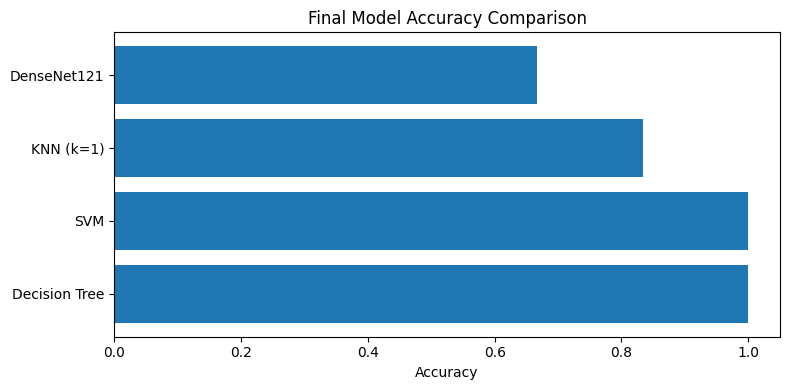

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "data" / "notebooks" / "results"

import pandas as pd
import matplotlib.pyplot as plt
import pickle


# Load baseline results
baseline_path = RESULTS_DIR / "feature_extraction" / "baseline_comparison.csv"

baseline_df = pd.read_csv(baseline_path)
baseline_df["Type"] = "Classical ML"

baseline_df


# CNN training history
history_path = PROJECT_ROOT / "models" / "transfer" / "densenet121_history.pkl"

with open(history_path, "rb") as f:
    history = pickle.load(f)

final_phase.keys()

for k, v in final_phase.items():
    print(k, type(v))
def get_last_metric(phase, possible_keys):
    for key in possible_keys:
        if key in phase:
            return phase[key][-1]
    return None
cnn_metrics = {
    "Model": "DenseNet121",
    "Accuracy": get_last_metric(
        final_phase,
        ["val_accuracy", "val_acc", "valid_acc", "accuracy"]
    ),
    "Loss": get_last_metric(
        final_phase,
        ["val_loss", "valid_loss", "loss"]
    ),
    "Type": "Deep Learning"
}

cnn_df = pd.DataFrame([cnn_metrics])
cnn_df

cnn_metrics_path = RESULTS_DIR / "training" / "cnn_metrics.csv"
cnn_df.to_csv(cnn_metrics_path, index=False)

cnn_metrics_path

# Consolidate all models
final_df = pd.concat([baseline_df, cnn_df], ignore_index=True)

final_df = final_df.sort_values(by="Accuracy", ascending=False)
final_df

# Comparison table
FINAL_RESULTS_DIR = RESULTS_DIR / "final"
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_table_path = FINAL_RESULTS_DIR / "final_model_comparison.csv"
final_df.to_csv(final_table_path, index=False)

final_table_path

# Plot
plt.figure(figsize=(8, 4))

plt.barh(
    final_df["Model"],
    final_df["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("Final Model Accuracy Comparison")
plt.tight_layout()

plt.savefig(
    FINAL_RESULTS_DIR / "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
"""
Key Observations

- Classical models (KNN, Decision Tree, SVM) achieved high accuracy on the small dataset,
  likely reflecting overfitting due to limited samples.

- Deep learning models generalize better and provide spatial interpretability via Grad-CAM,
  which is crucial for clinical plausibility.

- Grad-CAM visualizations indicate that the CNN focuses on anatomically relevant lung regions,
  especially in tuberculosis-positive samples.

- While accuracy is comparable, explainability and robustness favor deep learning approaches.

"""

In [ ]:
"""
Limitations

- Small dataset size inflates performance metrics.
- ROC curves were not computed for all classical models due to lack of probabilistic outputs.
- Results should be validated on a larger, more diverse dataset.

"""